# Clustering (Kümeleme)

## K-Means Kümeleme
* K-Means, veriyi k sayıda küme veya gruba ayırmayı amaçlayan bir algoritmadır.
* Çalışma prensibi:
  * **Küme sayısı belirleme**: İlk olarak kullanıcı belirli bir k sayıda küme sayısı seçer.
  * **Başlangıç merkezleri**: Rastgele k merkez (centroid) seçilir.
  * **Atama adımı**: Her veri noktası en yakın merkezle ilişkilendirilir.
  * **Güncelleme adımı**: Her küme için merkez, kümeye ait noktaların ortalaması alınarak güncellenir.
  * **Tekrarlama**: Atama ve güncelleme adımları, merkezlerin değişmediği veya çok az değiştiği noktaya kadar tekrar edilir.

### K-Means Kümeleme - Özellikler ve Kullanım
* **Özellikler**:
  * Basit ve hızlı: Genellikle büyük veri setleri için uygundur.
  * Küme sayısı belirlenmeli: K önceden belirlenmelidir.
  * Hassasiyet: Başlangıç merkezlerine duyarlıdır ve yerel minimumlara takılabilir.
* **Kullanım alanları**:
  * Pazar segmentasyonu
  * Görüntü sıkıştırma
  * Belirli özelliklere göre veri gruplama

### K-Means Kümeleme - Küme Seçme - Dirsek Metodu
* **Dirsek yöntemi (Elbow Method)**:
  * Farklı küme sayıları için küme içi varyans hesaplanır ve küme sayısına karşı inertia grafiği çizilir.
  * Grafiğin dirsek noktası, küme sayısı artışının getirisinin azaldığı ve küme sayısının daha fazla artmasının anlamlı bir iyileşme sağlamadığı noktayı gösterir.

### K-Means Kümeleme - Küme Seçme - Siluet Analizi
* **Siluet analizi**:
  * Her bir veri noktasının siluet değeri hesaplanır.
  * Siluet değeri, bir veri noktasının kendi kümesindeki diğer noktalara olan uzaklık ortalamasının, diğer kümelerdeki en yakın noktaya olan ortalama uzaklığa oranıdır. Siluet değeri -1 ile +1 arasında değişir.
  * **1**'e yakın değerler iyi kümelemeyi, **0**'a yakın değerler belirsiz kümelemeyi ve **-1**'e yakın değerler yanlış kümelemeyi gösterir.


In [17]:
# Kütüphanelerin yüklenmesi
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [18]:
# Veri seti oluşturma
n_samples = 300
random_state = 42
X, y = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.60, random_state=random_state)

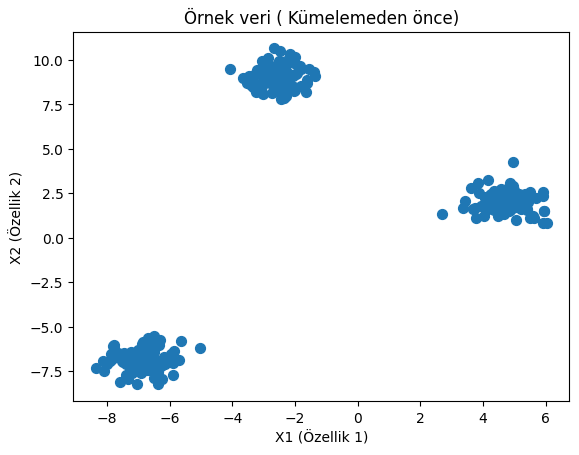

In [19]:
# Veriyi görselleştirme ( kümelemeden önce )
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Örnek veri ( Kümelemeden önce)')
plt.xlabel('X1 (Özellik 1)')
plt.ylabel('X2 (Özellik 2)')
plt.show()

In [20]:
# K-Means modelini oluşturma ve eğitim
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

In [21]:
# Küme Merkezlerini alma
centers = kmeans.cluster_centers_

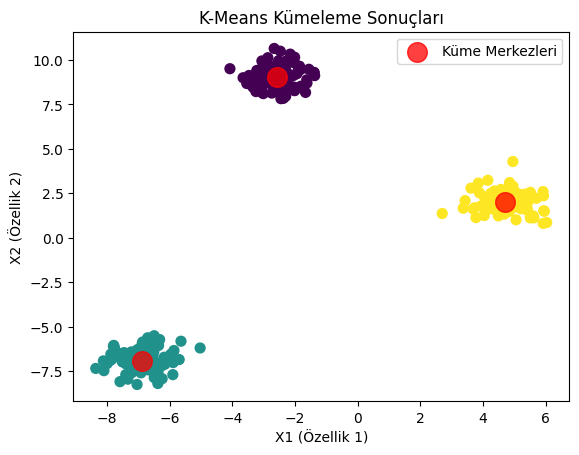

In [22]:
# Sonuçları görseleştirme
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, label="Küme Merkezleri")
plt.title('K-Means Kümeleme Sonuçları')
plt.xlabel('X1 (Özellik 1)')
plt.ylabel('X2 (Özellik 2)')
plt.legend()
plt.show()

In [23]:
# Küme etiketleri yazdırma
print("Küme Etiketleri:", y_kmeans)

Küme Etiketleri: [1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]


In [24]:
# Küme merkezlerini yazdırma
print("Küme Merkezleri:", centers)

Küme Merkezleri: [[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]


## Küme Seçimi
### Dirsek Methodu

In [25]:
# Dirsek Methodu için Inertia Hesaplama
inertia = []
range_n_clusters = range(1,11)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

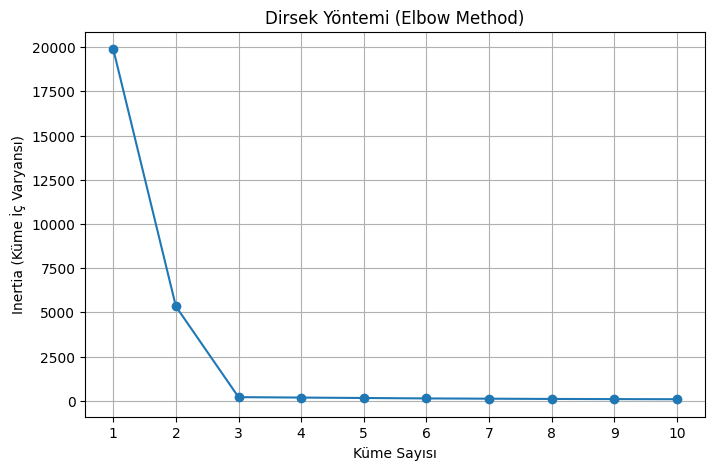

In [26]:
# Dirsek Methodu Grafiği Çizme
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Dirsek Yöntemi (Elbow Method)')
plt.xlabel('Küme Sayısı')
plt.ylabel('Inertia (Küme İç Varyansı)')
plt.xticks(range_n_clusters)
plt.grid()
plt.show()

### Siluet Analizi

In [27]:
from sklearn.metrics import silhouette_score ,silhouette_samples
silhouette_scores = []
for n_clusters in range_n_clusters[1:]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)


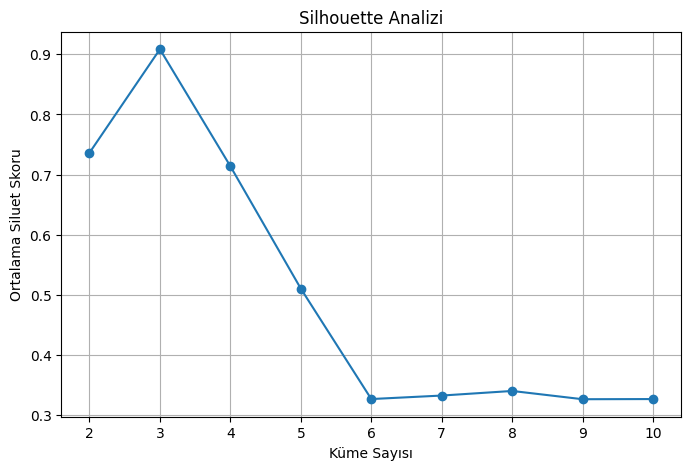

In [28]:
# Siluet Skoru Grafiği Çizme
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters[1:], silhouette_scores, marker='o')
plt.title('Silhouette Analizi')
plt.xlabel('Küme Sayısı')
plt.ylabel('Ortalama Siluet Skoru')
plt.xticks(range_n_clusters[1:])
plt.grid()
plt.show()

## Hiyerarşik Kümeleme
* Hiyerarşik kümeleme, veri noktalarını bir hiyerarşi içinde kümelmenin bir yoludur.
* Çalışma prensibi:
  * **Başlangıç**: Her veri noktası kendi kümesi olarak başlar (birinci seviyede).
  * **Birleştirme (Agglomerative)**: En yakın iki küme birleştirilir ve süreç, tüm noktalar tek bir küme haline gelene kadar devam eder.
  * **Bölme (Divisive)**: Tek bir küme, en küçük alt kümelere bölünene kadar bölünür.

### Hiyerarşik Kümeleme - Özellikler ve Kullanım
* **Özellikler**:
  * **Dendrogram**: Kümeleme süreci görsel olarak dendrogram (ağaç yapısı) ile gösterilebilir.
  * **Küme sayısı belirlenmeli**: Küme sayısı, dendrogramı keserek belirlenir.
  * **Esneklik**: Küme sayısı önceden belirlenmez, dinamik olarak ayarlanabilir.
* **Kullanım alanları**:
  * Genetik analiz
  * Biyoinformatik
  * Sosyal ağ analizi

### Hiyerarşik Kümeleme - Linkage Matrislerini Hesaplama
* linkage fonksiyonui hiyerrasik kümele adımlarınu temsil eden bir bağlantı matrisi oluşturu.farklı method parametleri ( ward,complete,average,sinhgle) farklı kümele yaklamlşarını temsil eder.
  * **Ward**: küme içi varyansı en aza indirmeye çalsıır bleirleştirecek iki küme  birleştikten sonraki toplam küme için varyansı en az artırandır
  * complete maksimum bğalntı: iki kümedkei tüm noka çiftyler arasındaki öaksimım mesafeyi en aza infirmeye çalsuıru
  * avereg ortlaam bğalamtı iki kümedik tüm npkta çiftleri arasındaki ortlama mesadeyi en aza indimey çALISIR
  * SİNHLE MİNİMUM Bbağlantı : ili küöedeki herhangşş iki nokta arasındaki minimum ömesafeyi en aza indirmeye çalısur bu zincirleme etkisine yakındır.



In [44]:
# Kütüpangeleri import etme
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [45]:
# Veri seti oluşturma
n_samples = 50
random_state = 42
X, y = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.60, random_state=random_state)

In [46]:
# farklı bğalantı türleri için linkage matrisleri hesaplama
linked_ward = linkage(X, method='ward')
linked_complete = linkage(X, method='complete')
linked_average = linkage(X, method='average')
linked_single = linkage(X, method='single')

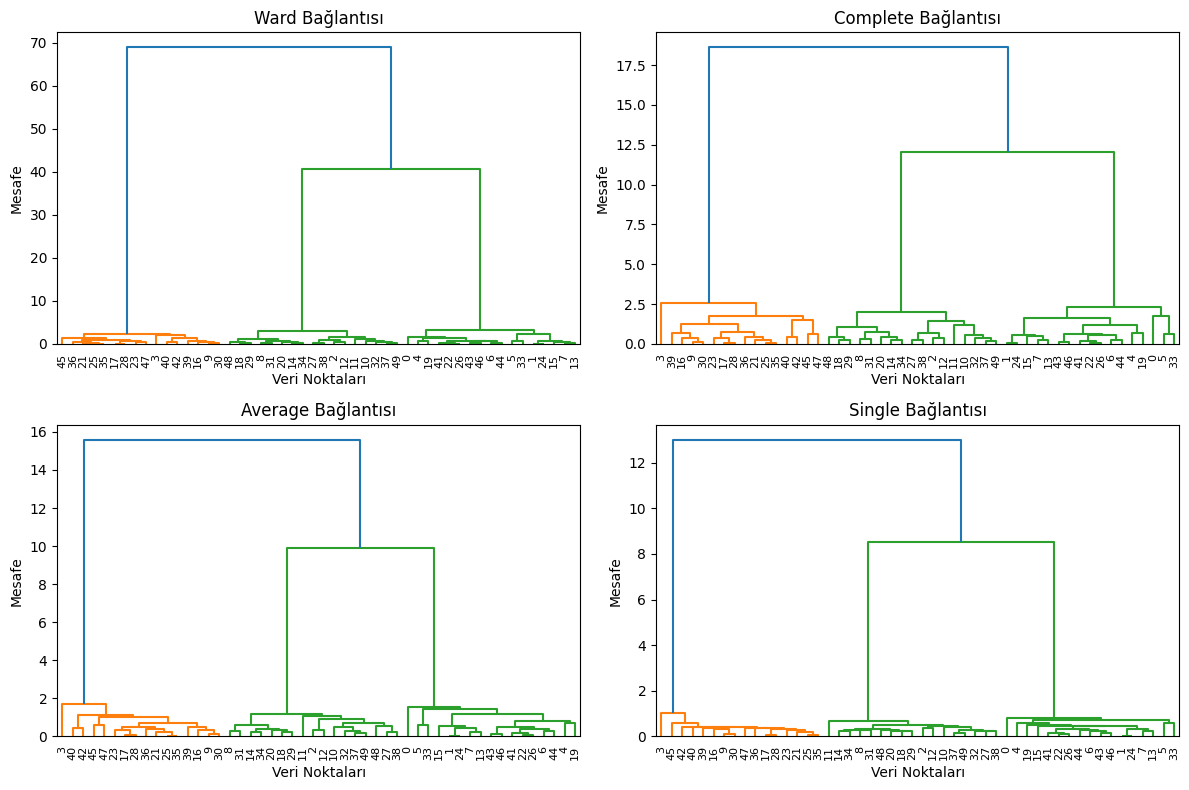

In [47]:
# Dendrogramları çizme
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
# Ward bağlantısı
dendrogram(linked_ward, orientation='top')
plt.title('Ward Bağlantısı')
plt.xlabel('Veri Noktaları')
plt.ylabel('Mesafe')
plt.subplot(2, 2, 2)

# Complete bağlantısı
dendrogram(linked_complete, orientation='top')
plt.title('Complete Bağlantısı')
plt.xlabel('Veri Noktaları')
plt.ylabel('Mesafe')
plt.subplot(2, 2, 3)

# Average bağlantısı
dendrogram(linked_average, orientation='top')
plt.title('Average Bağlantısı')
plt.xlabel('Veri Noktaları')
plt.ylabel('Mesafe')
plt.subplot(2, 2, 4)

# Single bağlantısı
dendrogram(linked_single, orientation='top')
plt.title('Single Bağlantısı')
plt.xlabel('Veri Noktaları')
plt.ylabel('Mesafe')


plt.tight_layout()
plt.show()

In [48]:
# Agglomerative Clustering kullanarak Kümeleme ( örneğin ward bağltanısı ve 3 küme )
n_clusters = 3
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
y_agg = agg_clustering.fit_predict(X)

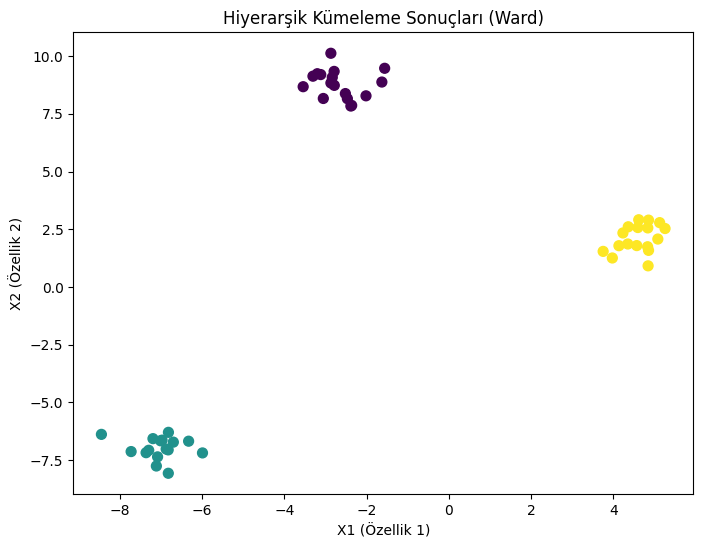

In [49]:
# Kümeleme Sonuçlarını Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_agg, s=50, cmap='viridis')
plt.title('Hiyerarşik Kümeleme Sonuçları (Ward)')
plt.xlabel('X1 (Özellik 1)')
plt.ylabel('X2 (Özellik 2)')
plt.show()

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
* DBSCAN, veriyi yoğunluk tabanlı olarak kümeleyen bir y��ntemdir ve **aykırı değerleri** tanımlamak için kullanılır.
* Çalışma prensibi:
  * **Çekirdek noktalar**: `eps` mesafesi içinde `min_samples` sayıda komşuya sahip noktalar çekirdek nokta olarak kabul edilir.
  * **Kümeleme**: Çekirdek noktanın komşuları aynı kümeye dahil edilir.
  * **Aykırı değerler**: Çekirdek noktaların `eps` mesafesi içinde olmayan noktalar aykırı değer olarak belirlenir.

### DBSCAN - Özellikler ve Kullanım
* **Özellikler**:
  * **Parametreler**: `eps` (mesafe) ve `min_samples` (minimum komşu sayısı) ayarlanmalıdır.
  * **Esneklik**: Küme sayısı önceden belirlenmez ve verinin yoğunluk yapısına göre kümeleme yapar.
  * **Aykırı değerler**: Aykırı değerleri tanımlama yeteneğine sahiptir.
* **Kullanım Alanları**:
  * Coğrafi veri analizi
  * Gürültü verisi analizi
  * Anomali tespiti

### DBSCAN - Temel Kavramlar
* **Epsilon (`eps`)**: Bir nokta etrafındaki arama yarıçapını belirler. Bu yarıçap içindeki noktalara komşu denir.
* **Minimum nokta sayısı (`min_samples`)**: Bir noktanın çekirdek nokta (`core point`) olarak kabul edilmesi için `eps` yarıçapı içinde bulunması gereken minimum komşu nokta sayısıdır (kendisi dahil).
* **Çekirdek nokta (`core point`)**: Etrafındaki `eps` yarıçapı içinde en az `min_samples` komşusu olan bir noktadır. Bir kümenin iç kısmında yer alır.
* **Sınır noktası (`border point`)**: Kendisi çekirdek nokta olmamasına rağmen bir çekirdek noktanın `eps` yarıçapı içinde yer alan bir noktadır. Bir kümenin sınırında yer alır.
* **Gürültü noktası (`noise point`)**: Ne çekirdek nokta olan ne de herhangi bir çekirdek noktanın `eps` yarıçapı içinde yer alan bir noktadır. Herhangi bir kümeye ait olmayan aykırı değer olarak kabul edilir.

### DBSCAN - Algoritması
1. **Başlangıç**: Veri setindeki tüm noktalar işlenmemiş olarak işaretlenir.
2. **Nokta seçimi**: İşlenmemiş bir nokta seçilir.
3. **Komşu bulma**: Seçilen noktanın `eps` yarıçapı içindeki komşuları bulunur.
4. **Çekirdek nokta kontrolü**: Eğer nokta çekirdek nokta ise kümeleme başlar.
5. **Kümeleme**: Nokta ve komşuları aynı kümeye atanır.
6. **Genişleme**: Komşuların her biri için adım 3-5 tekrarlanır.
7. **Tekrar**: Tüm noktalar işlenene kadar adım 2-6 tekrarlanır.

### DBSCAN - Avantaj ve Dezavantaj
* **Avantajlar**:
  * Küme sayısını önceden belirlemeye gerek yoktur.
  * Gürültü ve aykırı değerleri tanımlama yeteneği vardır.
  * Farklı yoğunluklarda kümeleri tespit edebilir.
* **Dezavantajlar**:
  * `eps` ve `min_samples` parametrelerinin doğru ayarlanması zor olabilir.
  * Küme şekilleri karmaşık olduğunda performansı düşebilir.
  * Yüksek boyutlu verilerde etkili olmayabilir.

### DBSCAN - Parametre Seçimi
* Epsilon eps için K-mesafe graiği:
  * her npkta için ıncı en yakın mkpmşı mesafesini görselletirin
  * grafikteki dirsek boktası pontasiyel eps değerini görselelşbilir
* Minimum Nokta Sayısı min_samples için:
  * genellikle 2 ile 5 arasında bir değer seçilir.
  * veri setinin yoğunluğuna bağlı olarak ayarlanabilir.
* Optics algoritması:
  * DBSCAN'ın bir genellemesidir.
  * Farklı yoğunluklarda kümeleri tespit edebilir.
  * Parametre ayarlama gereksinimini azaltır.
* Gaussian Mixture Model (GMM):
  * Veriyi birden fazla Gauss dağılımı ile modelleyerek kümeleme yapar.
  * Küme sayısını belirlemek için BIC veya AIC gibi kriterler kullanılabilir.
  * Daha esnek ve karmaşık veri yapıları için uygundur.


In [50]:
#DBSCAN Kümeleme
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [51]:
# Örnek veri oluşturma (daha karmaşık bir yapı)
n_samples = 300
random_state = 42
X, y = make_blobs(n_samples=n_samples, centers=[[1, 1], [5, 5], [3, 10]], cluster_std=[0.8, 0.8, 0.5], random_state=random_state)

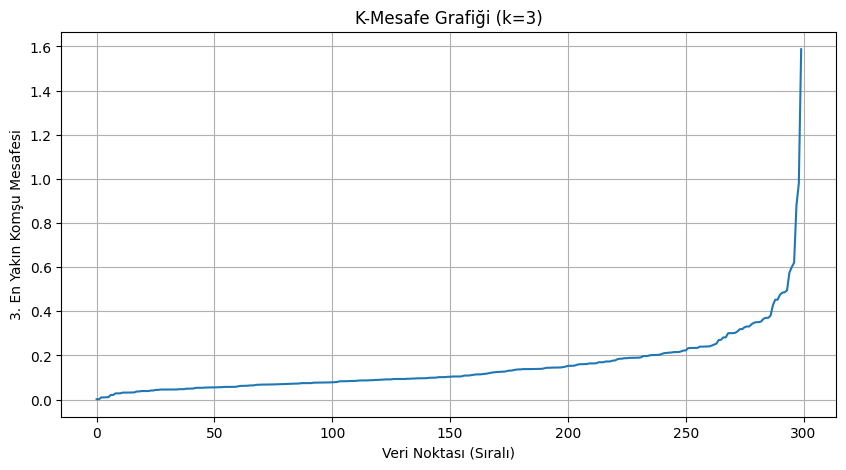

In [52]:
# 1. Epsilon (eps) seçimi için K-Mesafe Grafiği
neighbors = NearestNeighbors(n_neighbors=4)  # minPts = 3 + 1
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances, axis=0)
distances = distances[:, 1]  # k=3 için mesafeler (en yakın 3. komşuya uzaklık)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Mesafe Grafiği (k=3)')
plt.xlabel('Veri Noktası (Sıralı)')
plt.ylabel('3. En Yakın Komşu Mesafesi')
plt.grid(True)
plt.show()

# Grafikten tahmini eps değeri seçimi (dirsek noktasına bakarak)
estimated_eps = 0.6

In [53]:
# 2. DBSCAN Uygulaması (tahmini eps ve minPts=3 ile)
dbscan = DBSCAN(eps=estimated_eps, min_samples=3)
clusters = dbscan.fit_predict(X)

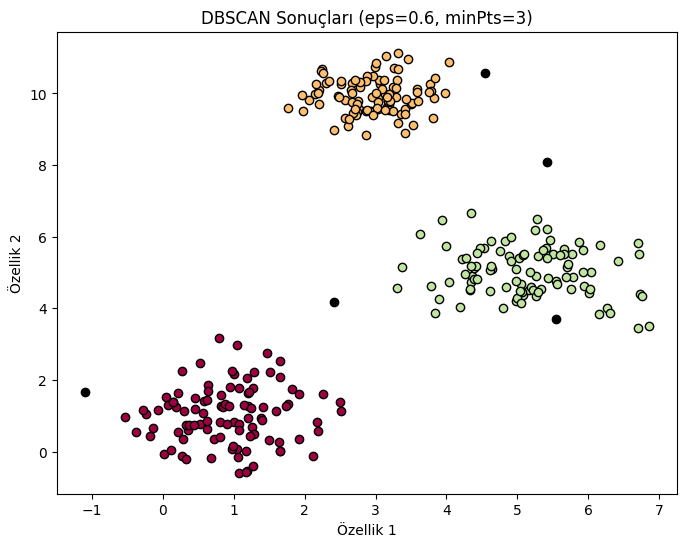

In [54]:
# Sonuçları görselleştirme
plt.figure(figsize=(8, 6))
unique_labels = set(clusters)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'  # Gürültü siyah renkte
    class_member_mask = (clusters == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)
plt.title(f'DBSCAN Sonuçları (eps={estimated_eps}, minPts=3)')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.show()

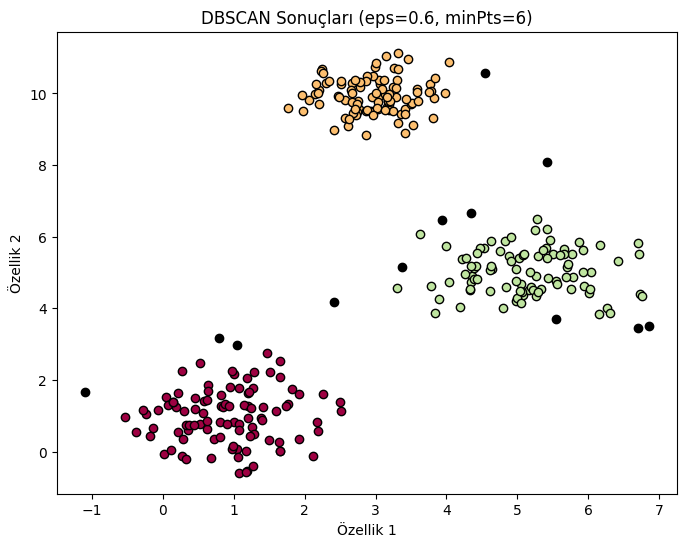

Küme Etiketleri (eps=0.6, minPts=3):
[ 0  0  1  2  0  0  1  0  0  2  0  0  1  1  1  0  0  0  0  2  1  1  0  1
  2  2  1  2  1  2  0  2  1  1  1  0  2  2  2  0  2  2  1  0  1  1  1  2
  1  1  0  0  1  2  2  2  1  0  2  1  0  2  0  2  1  2  1  0  1  1  2  2
  0  2  1  1  0  1  0  0  2  0  0  1  1  1  0  1  0  0  2  2  0  1  2  1
  2  0  0  0  0  0  2  1  0  0  2  0  1  1  2  2  2  0  1  2  1  0  1  1
  2  0  0  0  0  0  0  1  0  0  0  2  1  1  1  2  0  0  1  0  2 -1  0  2
  0  0  1  2  2  0  2  2  2  1  0  0  2  1  0  1  2  0  0  0  0  0  1  0
  1  1  1  0  2  1  1  0  1  2  2  1  2  0  2 -1  1  1  2  1  2  2  1  0
  1  0  0  2  2  0  1  1  1  2  0  0  2  2 -1  1  1  0  1  1  2  1  0  2
  1  1 -1  0  0  1  0  1  2  2  1  2  1  1  2  2  0  2  2  2  1  2  1  2
  2  2  1  2  0  0  2  1  1  2  1  1  0  0  0  1  0  2  2  1  2  2  0  0
  2  2  2  1  1  1  0  0  0  2  2  2  2  1  2  1  2  2  1  0  2  2 -1  1
  0  2  0  1  1  1  1  2  0  2  2  0]

Küme Etiketleri (eps=0.6, minPts=6):
[ 0  0  1  

In [55]:
# 3. DBSCAN Uygulaması (farklı minPts ile)
dbscan_alt = DBSCAN(eps=estimated_eps, min_samples=6)
clusters_alt = dbscan_alt.fit_predict(X)

# Alternatif sonuçları görselleştirme
plt.figure(figsize=(8, 6))
unique_labels_alt = set(clusters_alt)
colors_alt = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_alt))]
for k, col in zip(unique_labels_alt, colors_alt):
    if k == -1:
        col = 'k'  # Gürültü siyah renkte
    class_member_mask = (clusters_alt == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)
plt.title(f'DBSCAN Sonuçları (eps={estimated_eps}, minPts=6)')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.show()

# Küme etiketlerini yazdırma
print("Küme Etiketleri (eps={}, minPts=3):".format(estimated_eps))
print(clusters)
print("\nKüme Etiketleri (eps={}, minPts=6):".format(estimated_eps))
print(clusters_alt)